In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

training_data=pd.read_csv(r"C:\Users\HOME\OneDrive\Documents\New project\Agents_Practice\train_df.csv")
training_data.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [2]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                5000 non-null   int64 
 1   gender             5000 non-null   object
 2   primary_diagnosis  5000 non-null   object
 3   num_procedures     5000 non-null   int64 
 4   days_in_hospital   5000 non-null   int64 
 5   comorbidity_score  5000 non-null   int64 
 6   discharge_to       5000 non-null   object
 7   readmitted         5000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [3]:
training_data.describe()

,age,num_procedures,days_in_hospital,comorbidity_score,readmitted
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,53.299000,4.46100,7.396600,2.068600,0.188000
std,20.646851,2.88606,4.025587,1.422357,0.390751
min,18.000000,0.00000,1.000000,0.000000,0.000000
25%,36.000000,2.00000,4.000000,1.000000,0.000000
50%,53.000000,4.00000,7.000000,2.000000,0.000000
75%,71.000000,7.00000,11.000000,3.000000,0.000000
max,89.000000,9.00000,14.000000,4.000000,1.000000


In [5]:
# count of ones and zeroes in the target column
training_data['readmitted'].value_counts()

readmitted
0    4060
1     940
Name: count, dtype: int64

In [6]:
#any missing values in the dataset
training_data.isnull().sum()    

age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

In [36]:
#data preprocessing
#convert the categorical variables into numerical variables using one-hot encoding
training_data_encoded=pd.get_dummies(training_data,drop_first=True)
training_data_encoded.head()


,age,num_procedures,days_in_hospital,comorbidity_score,readmitted,gender_Male,primary_diagnosis_Diabetes,primary_diagnosis_Heart Disease,primary_diagnosis_Hypertension,primary_diagnosis_Kidney Disease,discharge_to_Home Health Care,discharge_to_Rehabilitation Facility,discharge_to_Skilled Nursing Facility
0,69,1,2,1,0,True,False,True,False,False,True,False,False
1,32,2,13,2,0,False,False,False,False,False,False,True,False
2,89,1,7,1,0,True,True,False,False,False,False,False,False
3,78,9,2,2,0,True,False,False,False,False,False,False,True
4,38,6,4,4,0,True,True,False,False,False,False,True,False


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

x,y=training_data_encoded.drop('readmitted',axis=1),training_data_encoded['readmitted']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 
model=DecisionTreeClassifier(max_depth=5, min_samples_leaf=100)
model.fit(x_train,y_train)  
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))   
print(confusion_matrix(y_test,y_pred))   


              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000

[[826   0]
 [174   0]]


c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

x,y=training_data_encoded.drop('readmitted',axis=1),training_data_encoded['readmitted']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 
model=DecisionTreeClassifier()
#print the number of leafs in the decision tree
model.fit(x_train,y_train) 
y_pred=model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))   
print(confusion_matrix(y_test,y_pred))  
print("Number of leafs in the decision tree:",model.get_n_leaves())
print("Depth of the decision tree:",model.get_depth())
  


              precision    recall  f1-score   support

           0       0.83      0.77      0.80       826
           1       0.17      0.22      0.19       174

    accuracy                           0.68      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.71      0.68      0.69      1000

[[637 189]
 [135  39]]
Number of leafs in the decision tree: 1112
Depth of the decision tree: 21


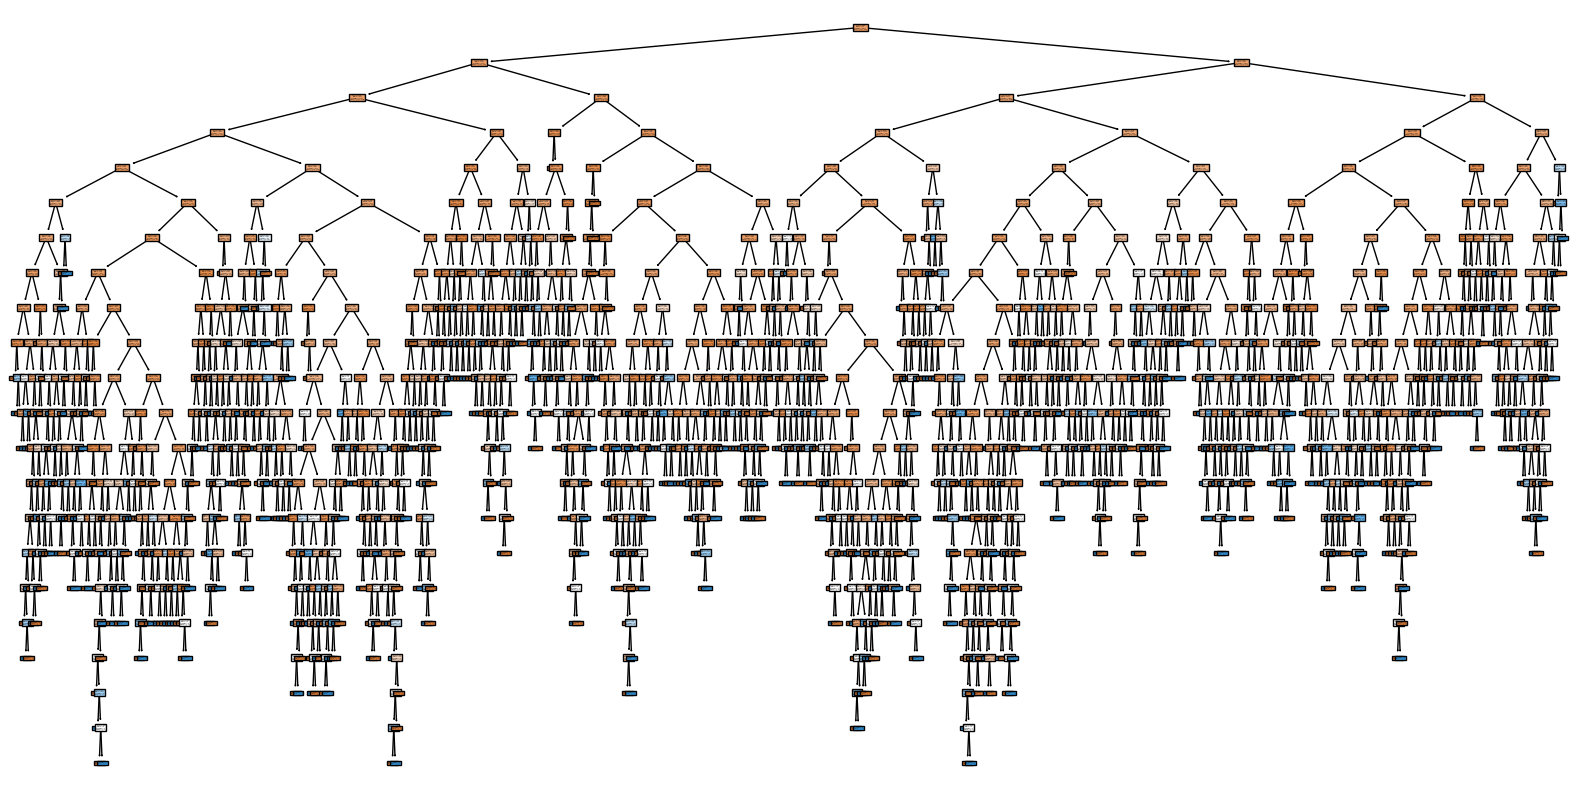

In [21]:
# visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,filled=True)
plt.show()

In [40]:
#give me an example from the dataset  in which the readmitted is one
training_data[training_data['readmitted']==1].head(1)   


,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
19,66,Female,COPD,3,7,2,Home Health Care,1


In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       826
           1       0.19      0.05      0.07       174

    accuracy                           0.80      1000
   macro avg       0.51      0.50      0.48      1000
weighted avg       0.72      0.80      0.75      1000



In [11]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)     
y_pred_nb=nb.predict(x_test)
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train) 
y_pred_lr=lr.predict(x_test)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=10,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print(classification_report(y_test,y_pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.97      0.89       826
           1       0.17      0.03      0.05       174

    accuracy                           0.81      1000
   macro avg       0.50      0.50      0.47      1000
weighted avg       0.71      0.81      0.75      1000



In [39]:
# built a frontend using streamlit to deploy the model
import streamlit as st
st.title("Readmission Prediction")
# create input fields for the user to enter the data
"""age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0"""
age=st.selectbox("Age",training_data['age'].unique())
gender=st.selectbox("Gender",training_data['gender'].unique())
primary_diagnosis=st.selectbox("Primary Diagnosis",training_data['primary_diagnosis'].unique())
num_procedures=st.number_input("Number of Procedures",min_value=0,max_value=10)
days_in_hospital=st.number_input("Days in Hospital",min_value=0,max_value=30)
comorbidity_score=st.number_input("Comorbidity Score",min_value=0,max_value=10)
discharge_to=st.selectbox("Discharge To",training_data['discharge_to'].unique())

# create a button to predict the readmission
if st.button("Predict"):
    # create a dataframe with the input data
    input_data=pd.DataFrame({'age':[age],
                             'gender':[gender], 
                                'primary_diagnosis':[primary_diagnosis],
                                'num_procedures':[num_procedures],
                                'days_in_hospital':[days_in_hospital],
                                'comorbidity_score':[comorbidity_score],
                                'discharge_to':[discharge_to]})
    # encode the input data
    input_data_encoded=pd.get_dummies(input_data,drop_first=True)
    # make the prediction
    prediction=model.predict(input_data_encoded)
    # display the prediction
    if prediction[0]==0:
        st.success("The patient is not likely to be readmitted within 30 days.")
    else:
        st.error("The patient is likely to be readmitted within 30 days.")  


        